## Data distribution shift analysis

Goal: compare the training period and validation period to see whether transaction patterns changed over time.

This matters because fraud models often perform worse when future data looks different from the data they were trained on.

#### Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#### Load the feature-engineered dataset

In [2]:
data = pd.read_parquet(
    "../data/processed/train_transaction_features.parquet",
    engine="fastparquet")

print("Data shape:", data.shape)

Data shape: (590540, 359)


#### Create same chronological split

In [3]:
split_index = int(len(data) * 0.8)

train_data = data.iloc[:split_index].copy()
validation_data = data.iloc[split_index:].copy()

print("Training rows:", len(train_data))
print("Validation rows:", len(validation_data))

Training rows: 472432
Validation rows: 118108


#### Compare fraud rate over time

In [4]:
train_fraud_rate = train_data['isFraud'].mean()
validation_fraud_rate = validation_data['isFraud'].mean()

print(f"Training fraud rate: {train_fraud_rate:.4%}")
print(f"Validation fraud rate: {validation_fraud_rate:.4%}")

Training fraud rate: 3.5135%
Validation fraud rate: 3.4409%


#### Compare fraud rate by transaction week

In [5]:
# Group by transaction_week and calculate fraud rate for each week
weekly_fraud_rate = (data
                     .groupby('transaction_week')['isFraud']
                     .mean()
                     .reset_index()
                     )

weekly_fraud_rate.head()

,transaction_week,isFraud
0,4,0.028541
1,5,0.035421


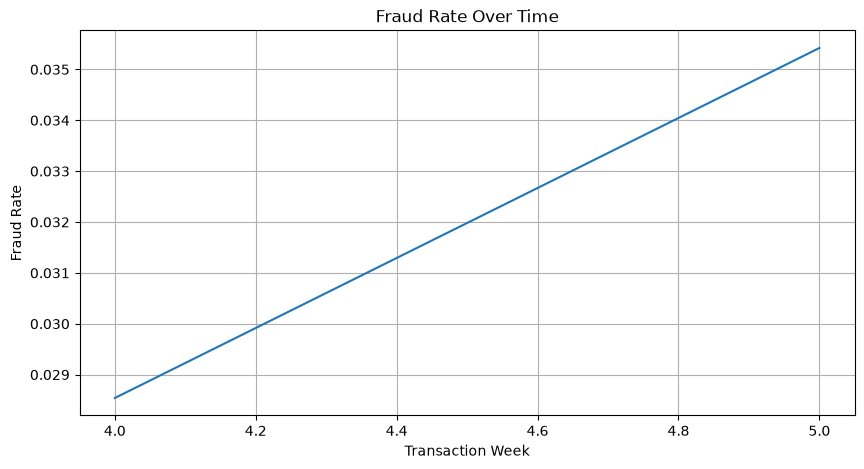

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_fraud_rate["transaction_week"],
    weekly_fraud_rate["isFraud"]
)

plt.xlabel("Transaction Week")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate Over Time")
plt.grid()
plt.show()

#### Select features to compare

In [7]:
features_to_check = [
    "TransactionAmt",
    "transaction_amount_log",
    "transaction_hour",
    "transaction_day",
    "card1_frequency",
    "card2_frequency",
    "card3_frequency",
    "card5_frequency"
]

# Keep only features that actually exist in the dataset
features_to_check = [
    feature for feature in features_to_check
    if feature in data.columns
]

features_to_check

['TransactionAmt',
 'transaction_amount_log',
 'transaction_hour',
 'transaction_day',
 'card1_frequency',
 'card2_frequency',
 'card3_frequency',
 'card5_frequency']

#### Compare training vs validation averages

In [ ]:
summary_rows = []

for feature in features_to_check:
    summary_rows.append({
        "feature": feature,
        "train_mean": train_data[feature].mean(),
        "validation_mean": validation_data[feature].mean(),
        "train_median": train_data[feature].median(),
        "validation_median": validation_data[feature].median(),
        "train_std": train_data[feature].std(),
        "validation_std": validation_data[feature].std()
    })

distribution_summary = pd.DataFrame(summary_rows)

distribution_summary

,feature,train_mean,validation_mean,train_median,train_std,validation_std
0,TransactionAmt,134.401388,68.500000,68.950000,237.557972,245.460936
1,transaction_amount_log,4.382521,4.241327,4.247781,0.934477,0.947933
2,transaction_hour,14.316446,16.619722,16.894167,7.683973,7.349555
3,transaction_day,36.786839,40.000000,37.000000,1.598013,0.457171
4,card1_frequency,2534.596482,936.000000,912.000000,3710.204923,3672.227283
5,card2_frequency,18312.794159,11310.000000,11310.000000,17635.095790,17811.427872
6,card3_frequency,466693.627640,522852.000000,522852.000000,153660.198599,143626.454270
7,card5_frequency,174203.558313,300805.000000,300805.000000,130450.865399,129951.607857


#### Add percentage change in mean

In [10]:
distribution_summary["mean_percent_change"] = (
    (
        distribution_summary["validation_mean"] -
        distribution_summary["train_mean"]
    )
    / distribution_summary["train_mean"]
) * 100

distribution_summary.sort_values(
    by="mean_percent_change",
    key=abs,
    ascending=False
)

,feature,train_mean,validation_mean,train_median,train_std,validation_std,mean_percent_change
7,card5_frequency,174203.558313,300805.000000,300805.000000,130450.865399,129951.607857,72.674429
4,card1_frequency,2534.596482,936.000000,912.000000,3710.204923,3672.227283,-63.071045
0,TransactionAmt,134.401388,68.500000,68.950000,237.557972,245.460936,-49.033264
5,card2_frequency,18312.794159,11310.000000,11310.000000,17635.095790,17811.427872,-38.239900
2,transaction_hour,14.316446,16.619722,16.894167,7.683973,7.349555,16.088327
6,card3_frequency,466693.627640,522852.000000,522852.000000,153660.198599,143626.454270,12.033242
3,transaction_day,36.786839,40.000000,37.000000,1.598013,0.457171,8.734539
1,transaction_amount_log,4.382521,4.241327,4.247781,0.934477,0.947933,-3.221763


#### Plot train vs validation distributions

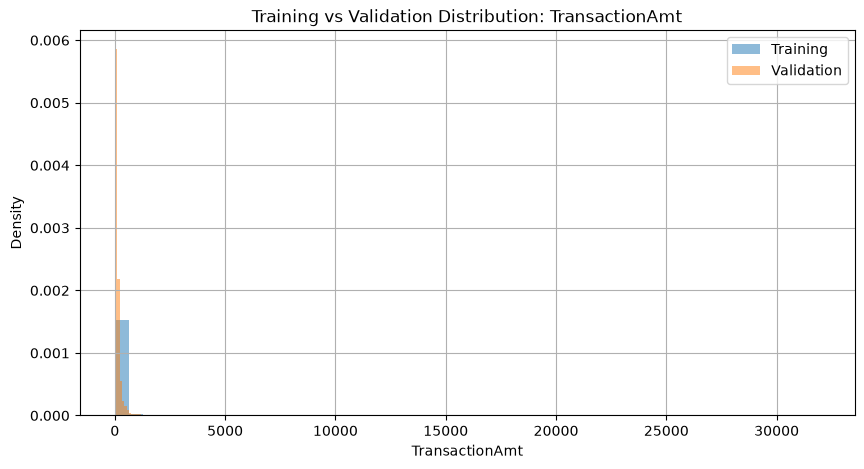

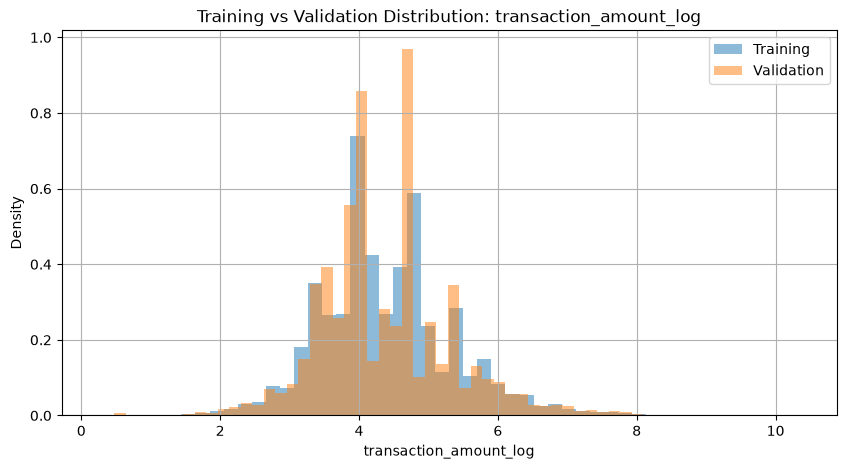

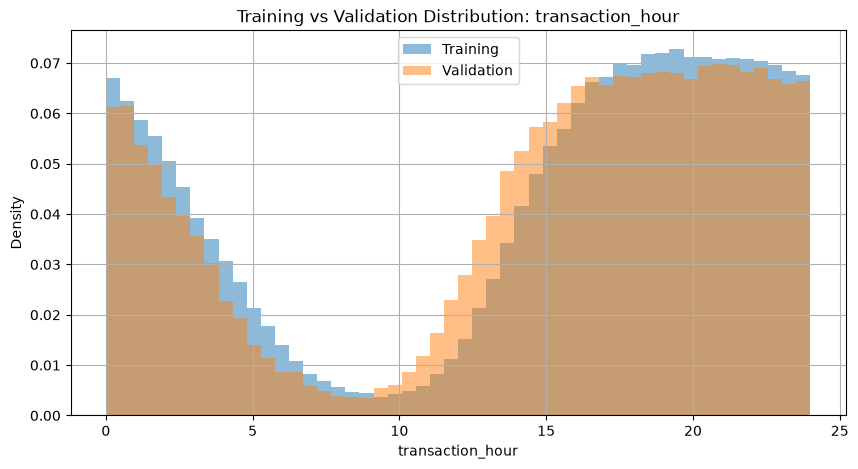

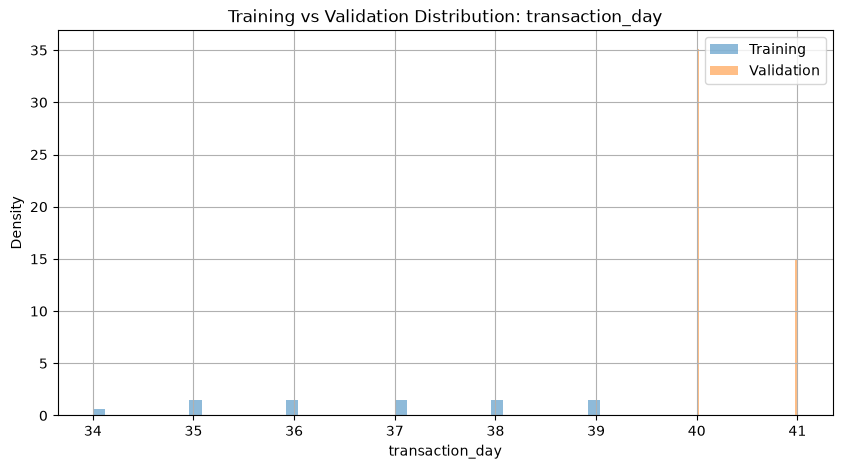

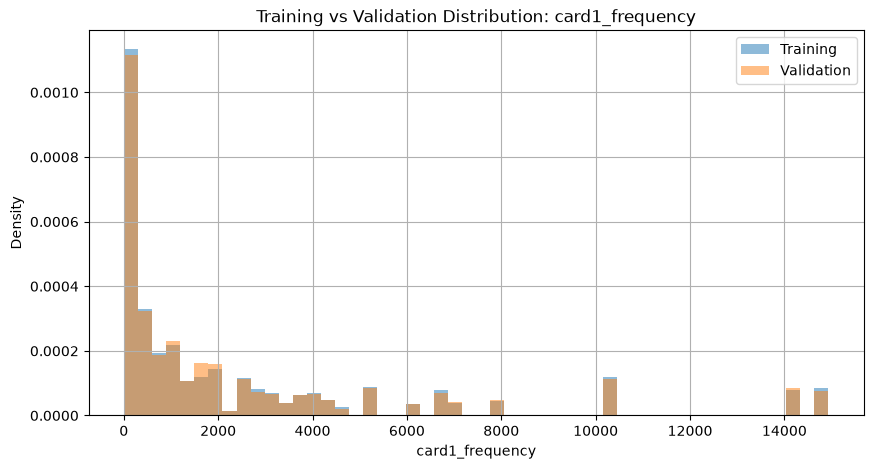

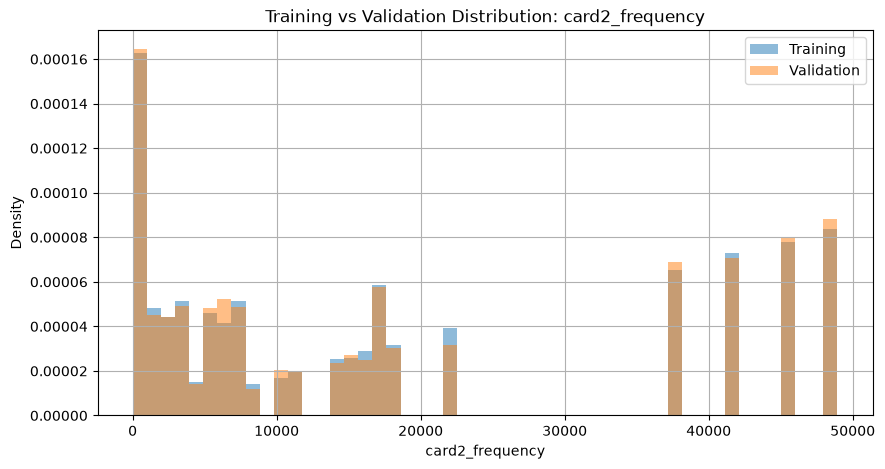

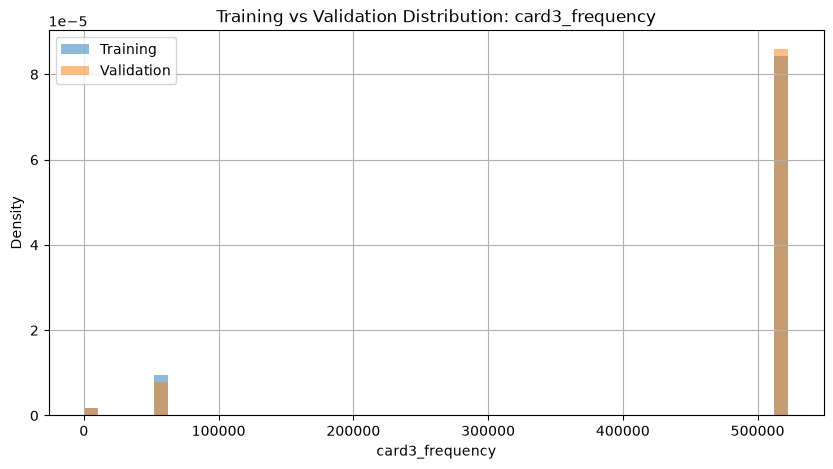

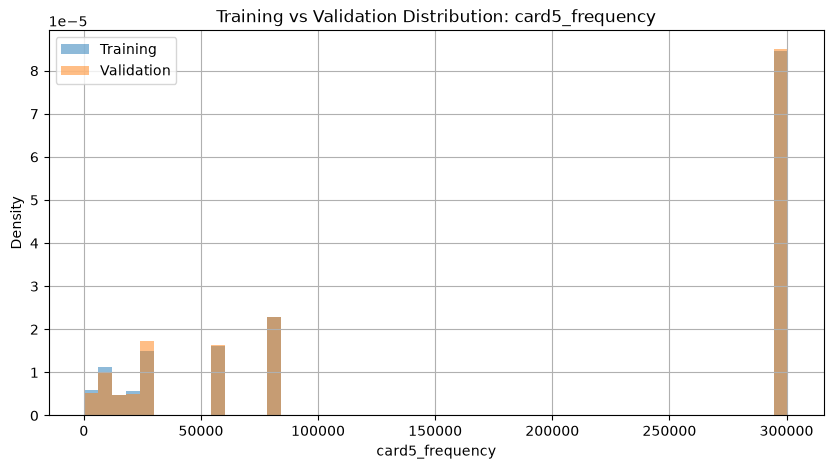

In [11]:
for feature in features_to_check:
    plt.figure(figsize=(10, 5))

    # Plot training distribution
    train_data[feature].plot(
        kind="hist",
        bins=50,
        alpha=0.5,
        density=True,
        label="Training"
    )

    # Plot validation distribution
    validation_data[feature].plot(
        kind="hist",
        bins=50,
        alpha=0.5,
        density=True,
        label="Validation"
    )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"Training vs Validation Distribution: {feature}")
    plt.legend()
    plt.grid()
    plt.show()

#### Calculate PSI: Population Stability Index
PSI is a common drift metric. It compares how much a feature’s distribution changes between two datasets.

In [12]:
def calculate_psi(expected, actual, buckets=10):
    expected = expected.dropna()
    actual = actual.dropna()

    # Create quantile-based breakpoints from the training data
    breakpoints = np.percentile(
        expected,
        np.linspace(0, 100, buckets + 1)
    )

    # Remove duplicate breakpoints
    # Duplicate breakpoints can happen if many values are the same
    breakpoints = np.unique(breakpoints)

    # If there are not enough unique breakpoints, PSI cannot be calculated well
    if len(breakpoints) < 3:
        return np.nan

    # Count values in each bin for training and validation
    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    # Convert counts to percentages
    expected_percents = expected_counts / len(expected)
    actual_percents = actual_counts / len(actual)

    # Replace zeros with a tiny value to avoid division by zero
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)

    # PSI formula
    psi_values = (
        actual_percents - expected_percents
    ) * np.log(actual_percents / expected_percents)

    return np.sum(psi_values)

#### Calculate PSI for selected features

In [13]:
psi_results = []

for feature in features_to_check:
    psi_score = calculate_psi(
        train_data[feature],
        validation_data[feature]
    )

    psi_results.append({
        "feature": feature,
        "psi": psi_score
    })

psi_results_df = pd.DataFrame(psi_results)

psi_results_df.sort_values(
    by="psi",
    ascending=False
)

,feature,psi
3,transaction_day,6.682574
2,transaction_hour,0.010205
1,transaction_amount_log,0.003976
0,TransactionAmt,0.003976
7,card5_frequency,0.003931
4,card1_frequency,0.003344
5,card2_frequency,0.002579
6,card3_frequency,0.000155


#### Label PSI severity

In [15]:
def label_psi_severity(psi):
    if pd.isna(psi):
        return "not_available"
    elif psi < 0.10:
        return "low_shift"
    elif psi < 0.25:
        return "moderate_shift"
    else:
        return "significant_shift"


psi_results_df["shift_level"] = psi_results_df["psi"].apply(label_psi_severity)

psi_results_df.sort_values(
    by="psi",
    ascending=False
)

,feature,psi,shift_level
3,transaction_day,6.682574,significant_shift
2,transaction_hour,0.010205,low_shift
1,transaction_amount_log,0.003976,low_shift
0,TransactionAmt,0.003976,low_shift
7,card5_frequency,0.003931,low_shift
4,card1_frequency,0.003344,low_shift
5,card2_frequency,0.002579,low_shift
6,card3_frequency,0.000155,low_shift


#### Save drift results

In [16]:
distribution_summary.to_csv(
    "../data/processed/distribution_summary.csv",
    index=False
)

psi_results_df.to_csv(
    "../data/processed/psi_results.csv",
    index=False
)

## Distribution Shift Analysis Summary

The dataset was split chronologically into an earlier training period and a later validation period to simulate how the fraud model would perform on future transactions.

The chronological split created:

* Training rows: 472,432
* Validation rows: 118,108

### Fraud Rate Comparison

* Training fraud rate: 3.5135%
* Validation fraud rate: 3.4409%

The fraud rate remained very similar between the training and validation periods. This suggests that the overall class balance did not change significantly over time.

### Features Checked for Distribution Shift

The following features were compared between the training and validation periods:

* `TransactionAmt`
* `transaction_amount_log`
* `transaction_hour`
* `transaction_day`
* `card1_frequency`
* `card2_frequency`
* `card3_frequency`
* `card5_frequency`

### PSI Analysis

Population Stability Index was used to measure how much selected feature distributions changed from the training period to the validation period.

PSI interpretation:

* Below 0.10: low shift
* 0.10 to 0.25: moderate shift
* Above 0.25: significant shift

### PSI Results

* `transaction_day`: 6.683 — significant shift
* `transaction_hour`: 0.010 — low shift
* `transaction_amount_log`: 0.004 — low shift
* `TransactionAmt`: 0.004 — low shift
* `card5_frequency`: 0.004 — low shift
* `card1_frequency`: 0.003 — low shift
* `card2_frequency`: 0.003 — low shift
* `card3_frequency`: 0.000 — low shift

### Interpretation

The only feature showing significant shift was `transaction_day`. This is expected because the dataset was intentionally split chronologically, meaning the training period contains earlier transaction days and the validation period contains later transaction days.

For the other checked features, PSI values were very low. This suggests that transaction amount, transaction hour, and selected card-frequency features were relatively stable between the training and validation periods.

The similar fraud rates between training and validation also suggest that the target distribution stayed stable across the split.

Overall, this analysis did not show strong evidence of problematic distribution shift in the main transaction features checked. However, the high PSI for `transaction_day` confirms that the validation set represents a later time period, which supports the use of chronological validation instead of a random split.

### Why This Matters

Distribution shift matters because a fraud model trained on one time period may perform worse if future transactions have different amounts, timing patterns, card patterns, or fraud rates.

This analysis helps validate that the model was tested in a more realistic future-facing setup while also checking whether key feature distributions changed meaningfully.

The drift analysis can later be reused in the deployed system to monitor whether live transaction data starts moving away from the original training distribution.
